In [76]:
import pandas as pd
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

## 📂 Data Acquisition

### 📥 Loading the Raw Dataset
---

In [77]:
df=pd.read_csv("../Data/Telco-Customer-Churn.csv")


## 📊 Exploratory Data Analysis

### 🔍 Analyzing Dataset Structure & Summary Statistics
---

In [78]:
print("--- First 5 Rows of the Dataset ---")
display(df.head())

print(f"Dataset Shape: {df.shape}\n")

print("--- Summary Statistics ---")
display(df.describe())

print("\n--- Dataset Info ---")
df.info()

print("\n--- Missing Values ---")
print(df.isnull().sum())


--- First 5 Rows of the Dataset ---


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


Dataset Shape: (7043, 21)

--- Summary Statistics ---


,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000



--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  70

## 📈 Data Transformation & Outlier Detection

### 🔄 Converting 'TotalCharges' & Visualizing Outliers
---

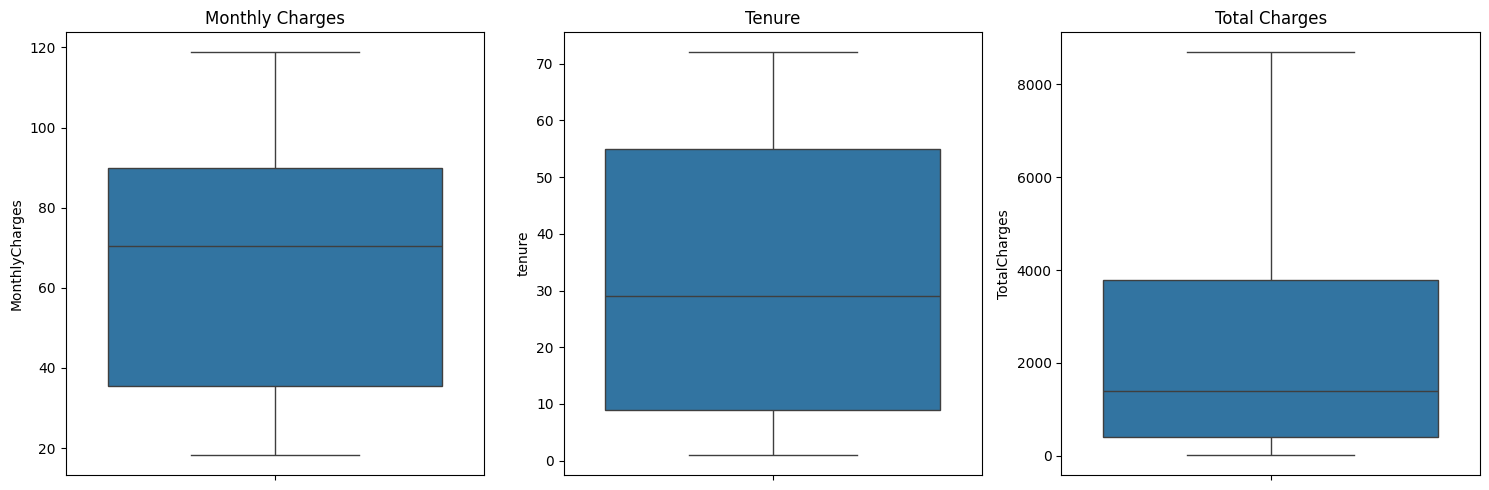

In [79]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df.dropna(subset=['TotalCharges'], inplace=True)

fig , axes = plt.subplots(1,3,figsize=(15,5))

sns.boxplot(df["MonthlyCharges"], ax=axes[0])
axes[0].set_title("Monthly Charges")

sns.boxplot(df["tenure"], ax=axes[1])
axes[1].set_title("Tenure")

sns.boxplot(df["TotalCharges"], ax=axes[2])
axes[2].set_title("Total Charges")

plt.tight_layout()
plt.show()


## 🎯 Target Class Distribution

### 📊 Analyzing Churn Proportions & Visualizing the Class Imbalance
---

--- Churn Counts ---
Churn
No     5163
Yes    1869
Name: count, dtype: int64

--- Churn Percentages (%) ---
Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


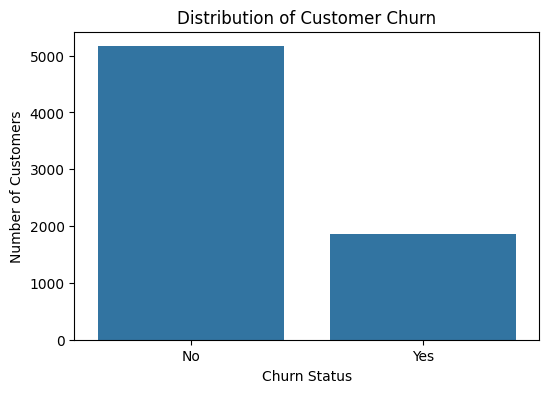

In [80]:
print("--- Churn Counts ---")
print(df["Churn"].value_counts())

print("\n--- Churn Percentages (%) ---")
print((df["Churn"].value_counts(normalize=True) * 100).round(2))

plt.figure(figsize=(6, 4))
sns.countplot(x=df["Churn"])
plt.title("Distribution of Customer Churn")
plt.xlabel("Churn Status")
plt.ylabel("Number of Customers")
plt.show()

## 🔍 Feature Exploration & Analysis

### 📊 Investigating Charges, and Contract Types by Churn
---

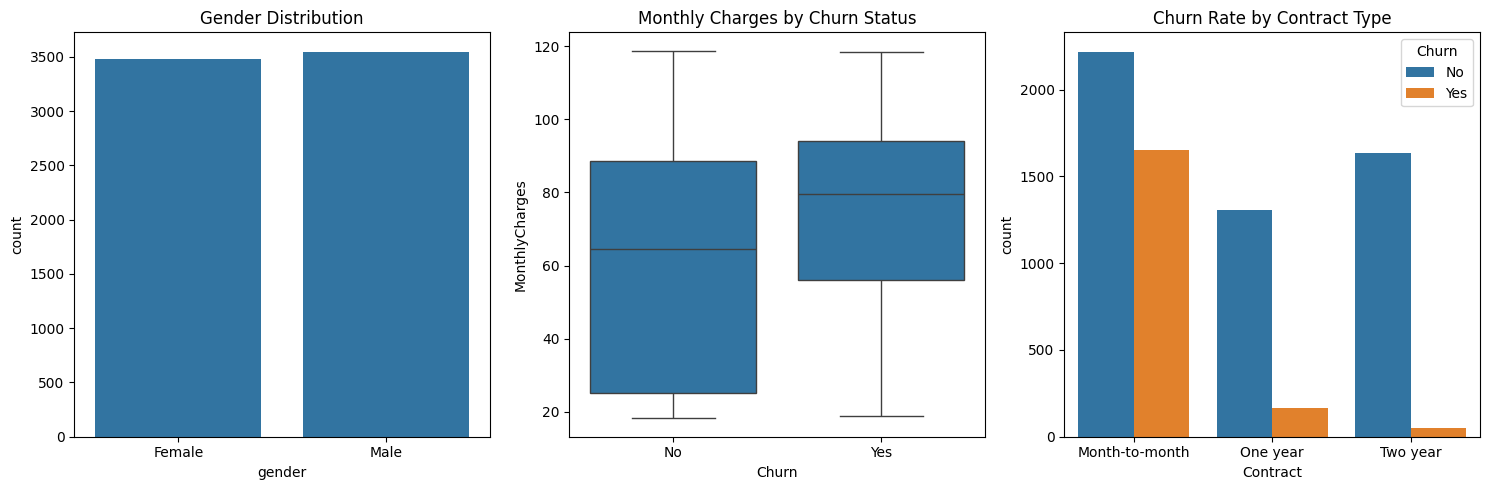

In [81]:
fig, axes = plt.subplots(1,3,figsize=(15,5))

sns.countplot(x="gender", data=df, ax=axes[0])
axes[0].set_title("Gender Distribution")

sns.boxplot(x="Churn", y="MonthlyCharges", data=df, ax=axes[1])
axes[1].set_title("Monthly Charges by Churn Status")

sns.countplot(x="Contract", hue="Churn", data=df, ax=axes[2])
axes[2].set_title("Churn Rate by Contract Type")

plt.tight_layout()
plt.show()

## 🗺️ Correlation Matrix

### 🌡️ Analyzing Linear Relationships Among Numeric Features
---

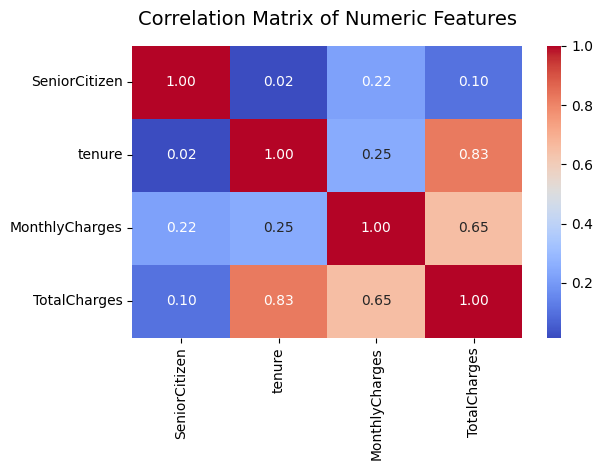

In [82]:
df_numeric=df.select_dtypes(include=[np.number])
sns.heatmap(data=df_numeric.corr(),annot=True,fmt=".2f",cmap="coolwarm")

plt.title("Correlation Matrix of Numeric Features", fontsize=14, pad=15)
plt.tight_layout()
plt.show()